In [1]:
import tensorflow as tf

if tf.config.list_physical_devices('GPU'):
    print("GPU available")
    print(tf.config.list_physical_devices('GPU'))
else:
    print("Using CPU")

Using CPU


In [3]:
# Install KaggleHub if needed
!pip install kagglehub

In [4]:
# Import required libraries
import kagglehub
import bz2
import os
import pandas as pd

In [5]:
# Download the Amazon Reviews dataset
path = kagglehub.dataset_download("bittlingmayer/amazonreviews")

print("Dataset path:", path)

100%|███████████████████████████████████████████████████████████████████████████████| 493M/493M [00:48<00:00, 10.8MB/s]

Extracting files...


Dataset path: C:\Users\rohit\.cache\kagglehub\datasets\bittlingmayer\amazonreviews\versions\7


In [6]:
# Check the downloaded dataset files
print(os.listdir(path))

['test.ft.txt.bz2', 'train.ft.txt.bz2']


In [7]:
# Set paths for training and test files
train_file = os.path.join(path, "train.ft.txt.bz2")
test_file = os.path.join(path, "test.ft.txt.bz2")

print(train_file)
print(test_file)

C:\Users\rohit\.cache\kagglehub\datasets\bittlingmayer\amazonreviews\versions\7\train.ft.txt.bz2
C:\Users\rohit\.cache\kagglehub\datasets\bittlingmayer\amazonreviews\versions\7\test.ft.txt.bz2


In [9]:
# Load the complete training dataset
reviews = []

with bz2.open(train_file, "rt", encoding="utf-8") as f:
    for line in f:
        label, text = line.strip().split(" ", 1)
        
        # Convert labels: 1 = Negative, 2 = Positive
        label = int(label[-1]) - 1
        
        reviews.append([text, label])

train = pd.DataFrame(
    reviews,
    columns=["text", "label"]
)

print("Train shape:", train.shape)

Train shape: (3600000, 2)


In [11]:
# Load the complete test dataset
reviews = []

with bz2.open(test_file, "rt", encoding="utf-8") as f:
    for line in f:
        label, text = line.strip().split(" ", 1)
        
        # Convert labels: 1 = Negative, 2 = Positive
        label = int(label[-1]) - 1
        
        reviews.append([text, label])

test = pd.DataFrame(
    reviews,
    columns=["text", "label"]
)

print("Test shape:", test.shape)

Test shape: (400000, 2)


In [12]:
# Check dataset information
print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\nSentiment distribution:")
print(train["label"].value_counts())

print("\nFirst 5 reviews:")
print(train.head())

Train shape: (3600000, 2)
Test shape: (400000, 2)

Sentiment distribution:
label
1    1800000
0    1800000
Name: count, dtype: int64

First 5 reviews:
                                                text  label
0  Stuning even for the non-gamer: This sound tra...      1
1  The best soundtrack ever to anything.: I'm rea...      1
2  Amazing!: This soundtrack is my favorite music...      1
3  Excellent Soundtrack: I truly like this soundt...      1
4  Remember, Pull Your Jaw Off The Floor After He...      1


In [13]:
print("\nColumn information:")
print(train.info())


Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600000 entries, 0 to 3599999
Data columns (total 2 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   text    object
 1   label   int64 
dtypes: int64(1), object(1)
memory usage: 54.9+ MB
None


In [14]:
# Check for missing values
print("Missing values:")
print(train.isnull().sum())

Missing values:
text     0
label    0
dtype: int64


In [15]:
# Check for duplicate reviews
print("Duplicate reviews:", train["text"].duplicated().sum())

Duplicate reviews: 0


label
1    1800000
0    1800000
Name: count, dtype: int64


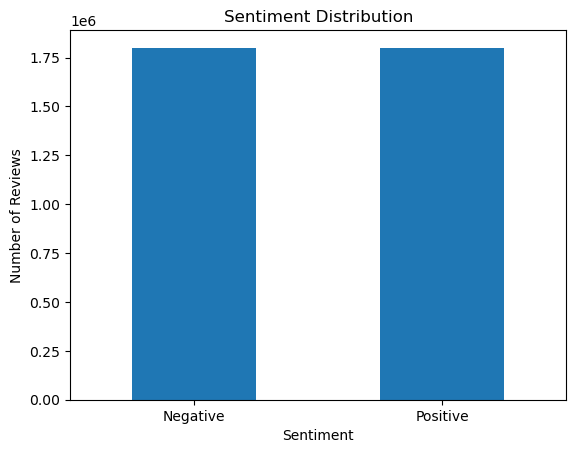

In [16]:
import matplotlib.pyplot as plt

# Check sentiment distribution
print(train["label"].value_counts())

# Plot sentiment distribution
train["label"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.title("Sentiment Distribution")
plt.xticks([0, 1], ["Negative", "Positive"], rotation=0)
plt.show()

In [17]:
# Calculate review length for EDA
review_length = train["text"].str.len()

print(review_length.describe())

count    3.600000e+06
mean     4.316463e+02
std      2.375526e+02
min      7.200000e+01
25%      2.310000e+02
50%      3.830000e+02
75%      5.950000e+02
max      1.015000e+03
Name: text, dtype: float64


In [18]:
# Calculate number of words in each review
word_count = train["text"].str.split().str.len()

print(word_count.describe())

count    3.600000e+06
mean     7.848273e+01
std      4.283280e+01
min      2.000000e+00
25%      4.200000e+01
50%      7.000000e+01
75%      1.080000e+02
max      2.570000e+02
Name: text, dtype: float64


In [19]:
# Compare average review length for each sentiment
print(
    train.assign(review_length=review_length)
         .groupby("label")["review_length"]
         .mean()
)

label
0    447.454261
1    415.838369
Name: review_length, dtype: float64


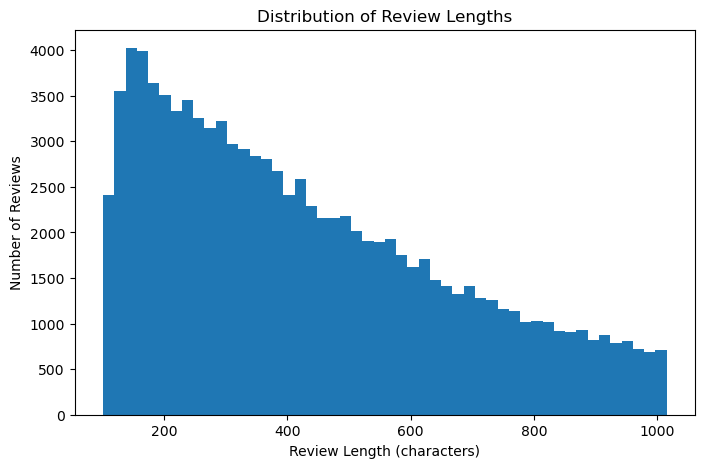

In [20]:
# Sample reviews for visualization
length_sample = train.sample(100000, random_state=42)

# Calculate review lengths
length_sample = length_sample["text"].str.len()

# Plot review length distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(length_sample, bins=50)

plt.xlabel("Review Length (characters)")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Review Lengths")

plt.show()

In [21]:
# Calculate word count for a sample
word_sample = train.sample(100000, random_state=42)

word_count_sample = word_sample["text"].str.split().str.len()

print(word_count_sample.describe())

count    100000.000000
mean         78.416680
std          42.828984
min          10.000000
25%          42.000000
50%          70.000000
75%         108.000000
max         210.000000
Name: text, dtype: float64


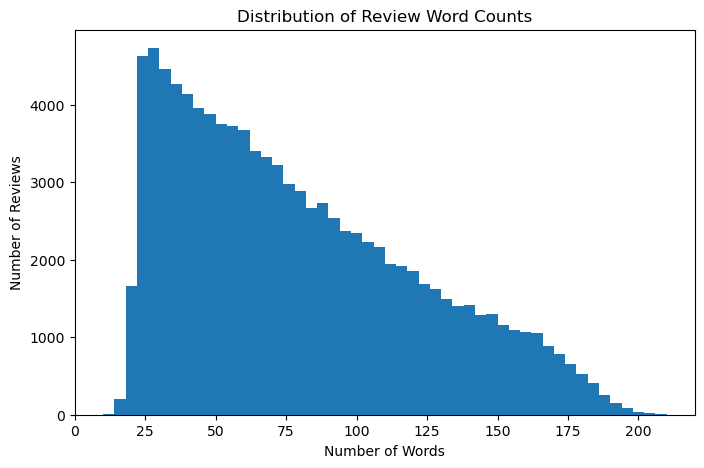

In [22]:
# Plot word count distribution
plt.figure(figsize=(8, 5))
plt.hist(word_count_sample, bins=50)

plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Review Word Counts")

plt.show()

In [23]:
# Take a sample for word frequency analysis
word_freq_sample = train.sample(100000, random_state=42)

# Combine reviews into one text
all_text = " ".join(word_freq_sample["text"])

# Split text into words
words = all_text.lower().split()

# Count the most common words
from collections import Counter

word_counts = Counter(words)

# Display the 20 most common words
print(word_counts.most_common(20))

[('the', 389970), ('and', 210513), ('i', 199657), ('a', 198624), ('to', 189997), ('of', 157241), ('this', 139196), ('is', 135054), ('it', 132731), ('in', 89080), ('for', 85211), ('that', 73446), ('was', 65781), ('not', 61891), ('you', 59002), ('with', 56091), ('but', 54835), ('on', 52796), ('my', 50521), ('have', 50516)]


In [24]:
# Take a sample for sentiment-specific word analysis
sentiment_sample = train.sample(100000, random_state=42)

# Separate positive and negative reviews
positive_text = " ".join(
    sentiment_sample[sentiment_sample["label"] == 1]["text"]
)

negative_text = " ".join(
    sentiment_sample[sentiment_sample["label"] == 0]["text"]
)

# Split reviews into words
positive_words = positive_text.lower().split()
negative_words = negative_text.lower().split()

# Count word frequencies
from collections import Counter

positive_counts = Counter(positive_words)
negative_counts = Counter(negative_words)

# Display the most common words
print("Top Positive Words:")
print(positive_counts.most_common(20))

print("\nTop Negative Words:")
print(negative_counts.most_common(20))

Top Positive Words:
[('the', 183582), ('and', 111544), ('a', 100334), ('i', 90062), ('to', 90014), ('of', 79160), ('is', 69831), ('this', 66463), ('it', 60489), ('in', 45284), ('for', 43843), ('that', 33977), ('you', 30578), ('with', 28467), ('my', 26649), ('was', 25968), ('on', 24454), ('but', 24035), ('have', 23650), ('as', 22511)]

Top Negative Words:
[('the', 206388), ('i', 109595), ('to', 99983), ('and', 98969), ('a', 98290), ('of', 78081), ('this', 72733), ('it', 72242), ('is', 65223), ('in', 43796), ('not', 43513), ('for', 41368), ('was', 39813), ('that', 39469), ('but', 30800), ('you', 28424), ('on', 28342), ('with', 27624), ('have', 26866), ('my', 23872)]


In [25]:
# Display some positive and negative reviews
print("POSITIVE REVIEWS:\n")

for text in train[train["label"] == 1]["text"].sample(3, random_state=42):
    print(text)
    print("-" * 100)

print("\nNEGATIVE REVIEWS:\n")

for text in train[train["label"] == 0]["text"].sample(3, random_state=42):
    print(text)
    print("-" * 100)

POSITIVE REVIEWS:

Perfect Mantra: I've been looking for this mantra for a long time. My children at yoga and me are very glad that this lotus mantra is making our class more enjoyable. Recommended even for adults with the motion of lotusflower opening and going back into the ground.
----------------------------------------------------------------------------------------------------
Quality: I'm just a little disapointed with the quality of the Metal Case, cause the only thing I saw was the photo on the web
----------------------------------------------------------------------------------------------------
Exceptional murder-mystery writer scores big.: Being a purveyor of exceptional mystery and crime novels, what a pleasant surprise to find one of my random picks turning out so well. Parker has an uncanny grasp of the lifestyle in orange county and a keen insight into the personalities of its inhabitants. Naughton is a true crime noir treat, and Parker's personalization of him evokes 

In [26]:
# Check for HTML tags in a sample
sample_text = train["text"].sample(100000, random_state=42)

html_count = sample_text.str.contains(r"<[^>]+>", regex=True).sum()

print("Reviews containing HTML tags:", html_count)
print("Percentage:", html_count / len(sample_text) * 100)


Reviews containing HTML tags: 60
Percentage: 0.06


In [27]:
# Basic text preprocessing
import re

# Convert text to lowercase
train["text"] = train["text"].str.lower()
test["text"] = test["text"].str.lower()

# Remove HTML tags
train["text"] = train["text"].str.replace(r"<[^>]+>", " ", regex=True)
test["text"] = test["text"].str.replace(r"<[^>]+>", " ", regex=True)

# Remove extra whitespace
train["text"] = train["text"].str.replace(r"\s+", " ", regex=True).str.strip()
test["text"] = test["text"].str.replace(r"\s+", " ", regex=True).str.strip()

print("Preprocessing completed.")
print("\nExample:")
print(train["text"].iloc[0])

Preprocessing completed.

Example:
stuning even for the non-gamer: this sound track was beautiful! it paints the senery in your mind so well i would recomend it even to people who hate vid. game music! i have played the game chrono cross but out of all of the games i have ever played it has the best music! it backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. it would impress anyone who cares to listen! ^_^


In [28]:
# Create tokenizer
from tensorflow.keras.preprocessing.text import Tokenizer

# Set vocabulary size
vocab_size = 30000

# Create tokenizer
tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)

# Learn the vocabulary from training reviews
tokenizer.fit_on_texts(train["text"])

print("Vocabulary size:", len(tokenizer.word_index))

Vocabulary size: 1102800


In [29]:
# Calculate word counts on the full training dataset
word_lengths = train["text"].str.split().str.len()

# Check important percentiles
print("50th percentile:", word_lengths.quantile(0.50))
print("75th percentile:", word_lengths.quantile(0.75))
print("90th percentile:", word_lengths.quantile(0.90))
print("95th percentile:", word_lengths.quantile(0.95))
print("99th percentile:", word_lengths.quantile(0.99))
print("Maximum:", word_lengths.max())

50th percentile: 70.0
75th percentile: 108.0
90th percentile: 144.0
95th percentile: 161.0
99th percentile: 181.0
Maximum: 257


In [30]:
!pip install pyarrow

In [31]:
# Save processed datasets in Parquet format
train.to_parquet("amazon_train_processed.parquet", index=False, compression="snappy")
test.to_parquet("amazon_test_processed.parquet", index=False, compression="snappy")

print("Processed datasets saved successfully.")
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Processed datasets saved successfully.
Train shape: (3600000, 2)
Test shape: (400000, 2)


In [32]:
# Save tokenizer
with open("amazon_tokenizer.json", "w", encoding="utf-8") as f:
    f.write(tokenizer.to_json())

print("Tokenizer saved successfully.")

Tokenizer saved successfully.


In [33]:
# Save important preprocessing settings
import json

config = {
    "vocab_size": 30000,
    "max_sequence_length": 200,
    "num_classes": 2
}

with open("amazon_config.json", "w") as f:
    json.dump(config, f, indent=4)

print("Configuration saved successfully.")

Configuration saved successfully.
